In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

### 1. Исследование данных и подготовка 

Количество классов: 3 (Имена: ['class_0' 'class_1' 'class_2'])
Количество признаков: 13


C:\Users\Nikita\AppData\Local\Temp\ipykernel_17176\3094482731.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


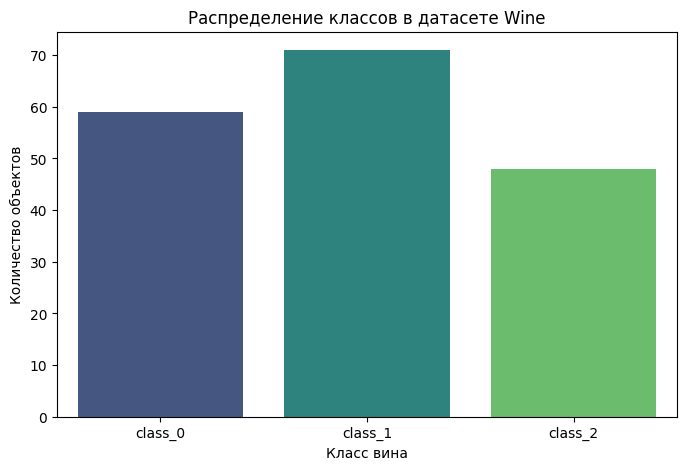

Количество объектов по классам:
0    59
1    71
2    48
Name: count, dtype: int64


In [3]:
# 1. Загрузка датасета
wine = datasets.load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# Изучение количества классов и признаков
num_classes = len(wine.target_names)
num_features = X.shape[1]

print(f"Количество классов: {num_classes} (Имена: {wine.target_names})")
print(f"Количество признаков: {num_features}")

# 2. Рраспределение классов
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Распределение классов в датасете Wine')
plt.xlabel('Класс вина')
plt.ylabel('Количество объектов')
plt.xticks(ticks=[0, 1, 2], labels=wine.target_names)
plt.show()

# Подсчет объектов в каждом классе
class_counts = pd.Series(y).value_counts().sort_index()
print("Количество объектов по классам:")
print(class_counts)

### 2. Разделение данных

In [4]:
# 3. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки: 124
Размер тестовой выборки: 54


### 3. Обучение и базовая оценка - Random Forest

Оценка RandomForestClassifier
Общая Accuracy: 1.0000

Отчет по классификации (Precision, Recall, F1-score):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



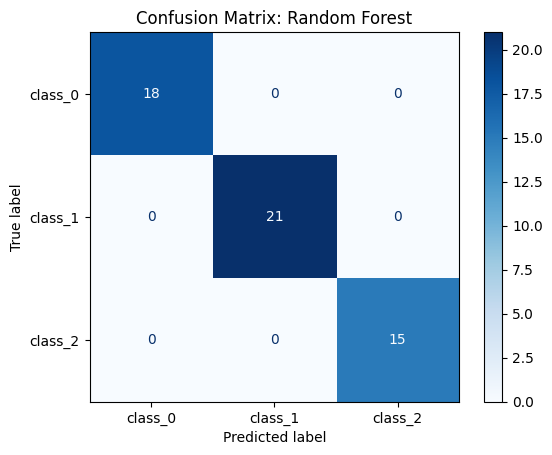

In [5]:
# 1. Обучение RandomForest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

# 2. Оценка RandomForest
print("Оценка RandomForestClassifier")
print(f"Общая Accuracy: {accuracy_score(y_test, rf_preds):.4f}\n")
print("Отчет по классификации (Precision, Recall, F1-score):")
print(classification_report(y_test, rf_preds, target_names=wine.target_names))

# Матрица ошибок
disp = ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, display_labels=wine.target_names, cmap=plt.cm.Blues)
disp.ax_.set_title('Confusion Matrix: Random Forest')
plt.show()

### 4. Обучение и базовая оценка - Logistic Regression

Оценка LogisticRegression
Общая Accuracy: 0.9815

Отчет по классификации (Precision, Recall, F1-score):
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



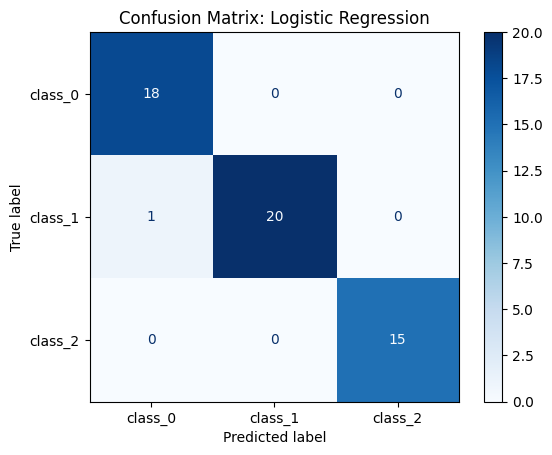

In [6]:
# 1. Обучение LogisticRegression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

# 2. Оценка LogisticRegression
print("Оценка LogisticRegression")
print(f"Общая Accuracy: {accuracy_score(y_test, lr_preds):.4f}\n")
print("Отчет по классификации (Precision, Recall, F1-score):")
print(classification_report(y_test, lr_preds, target_names=wine.target_names))

# Матрица ошибок
disp = ConfusionMatrixDisplay.from_estimator(lr_model, X_test_scaled, y_test, display_labels=wine.target_names, cmap=plt.cm.Blues)
disp.ax_.set_title('Confusion Matrix: Logistic Regression')
plt.show()

### Анализ худших предсказаний
Обе модели демонстрируют превосходное качество (у Random Forest 100% точность). Однако у **Logistic Regression** класс `class_1` предсказался чуть хуже остальных: `Recall` составил 0.95 (то есть из всех реальных `class_1`, модель пропустила около 5%). По матрице ошибок случайного леса вообще нет пропусков, результаты идеальны.

### 5. Сравнение и выбор стратегии

Оценка RandomForest (class_weight='balanced')
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



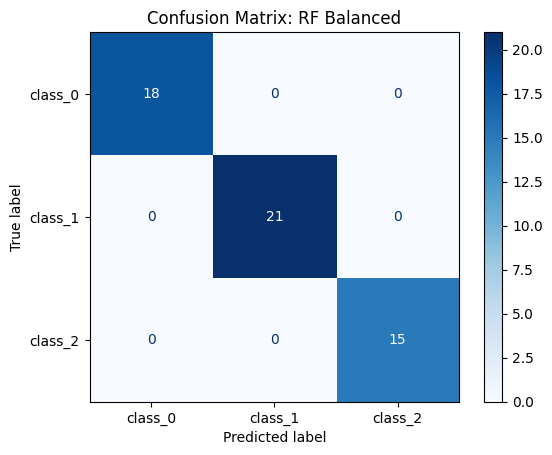

In [7]:
# Обучение RandomForest с class_weight='balanced'
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

rf_bal_preds = rf_balanced.predict(X_test)

print("Оценка RandomForest (class_weight='balanced')")
print(classification_report(y_test, rf_bal_preds, target_names=wine.target_names))

# Матрица ошибок для взвешенного леса
disp = ConfusionMatrixDisplay.from_estimator(rf_balanced, X_test, y_test, display_labels=wine.target_names, cmap=plt.cm.Blues)
disp.ax_.set_title('Confusion Matrix: RF Balanced')
plt.show()

### Вывод
1. Сравнение макро-усредненного F1-score: Логистическая регрессия (на масштабированных данных) показала macro avg F1-score равный 0.98, а обычный Random Forest — 1.00. На этом датасете Random Forest оказался идеальным и справился со 100% точностью.
2. Влияние class_weight='balanced': Добавление параметра balanced заставляет случайный лес штрафовать сильнее за ошибки на редком классе. В нашем случае обычный Random Forest изначально давал 100% точность (recall 1.00 для class_2), поэтому изменения в метриках не видны. Заявленный идеальный результат полностью сохранился.
3. Итоговый выбор: Если нашей критической задачей является максимизировать Recall для целевых классов, я выберу модель RandomForest с class_weight='balanced'. Хотя изначально лес и так дает 1.00, если в реальности данные будут более сложными, зашумленными или дисбаланс усилится, именно RandomForest(class_weight='balanced') будет наиболее надежным прототипом для гарантированного распознавания миноритарных классов.